# Spam Classification — Preprocessing, Outlier Analysis & Modeling

**Dataset:** Enron-Spam email corpus, sampled to a 60/40 ham/spam split (`enron_40_60.csv`) — real corporate emails, columns `Category` (ham/spam) and `Message`.

**Pipeline:**
1. Load & inspect
2. Missing value analysis and cleanup (duplicates, invalid rows)
3. Visualizations (class distribution, length distributions vs. an ideal normal curve)
4. Feature engineering (numeric features from raw text)
5. Outlier detection (IQR method) — before/after comparison
6. Classification model (TF-IDF + Multinomial Naive Bayes) — before vs. after outlier removal
7. Full evaluation: accuracy, precision, recall, F1, ROC-AUC, confusion matrix, confidence scores
8. Threshold tuning (precision/recall trade-off)
9. Live prediction demo


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 2. Load the dataset

In [2]:
# Works both in Google Colab (prompts for upload) and locally
# (assumes enron_40_60.csv is already in the working directory)
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    pass

df = pd.read_csv("enron_40_60.csv")
print("Shape:", df.shape)
df.head()


Shape: (27575, 2)


,Category,Message
0,spam,"re : loonger hello , do you want to spend iess..."
1,ham,unify to sap interfaces - - - - - - - - - - - ...
2,ham,start date : 1 / 28 / 02 ; hourahead hour : 10...
3,spam,want to make a million ! ! ! ! ! ! ! ! ! ! ! !...
4,ham,key dates and impact of upcoming sap implement...


In [3]:
print(df.columns.tolist())
print()
df.info()


['Category', 'Message']

<class 'pandas.DataFrame'>
RangeIndex: 27575 entries, 0 to 27574
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  27575 non-null  str  
 1   Message   27575 non-null  str  
dtypes: str(2)
memory usage: 431.0 KB


## 3. Missing value analysis and cleanup

Checks actual `NaN` values, then removes exact duplicate messages, which are
common in real email corpora (forwarded threads, re-sends).


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

before = df.shape[0]
df = df.dropna(subset=["Category", "Message"]).drop_duplicates(subset=["Message"]).reset_index(drop=True)
after = df.shape[0]
print(f"\nRows before: {before} | after: {after} | removed: {before - after}")

df["label_num"] = df["Category"].map({"ham": 0, "spam": 1})
print()
print(df["Category"].value_counts())
print((df["Category"].value_counts(normalize=True) * 100).round(2))


Missing values per column:
Category    0
Message     0
dtype: int64

Rows before: 27575 | after: 25865 | removed: 1710

Category
ham     15910
spam     9955
Name: count, dtype: int64
Category
ham     61.51
spam    38.49
Name: proportion, dtype: float64


## 4. Class distribution

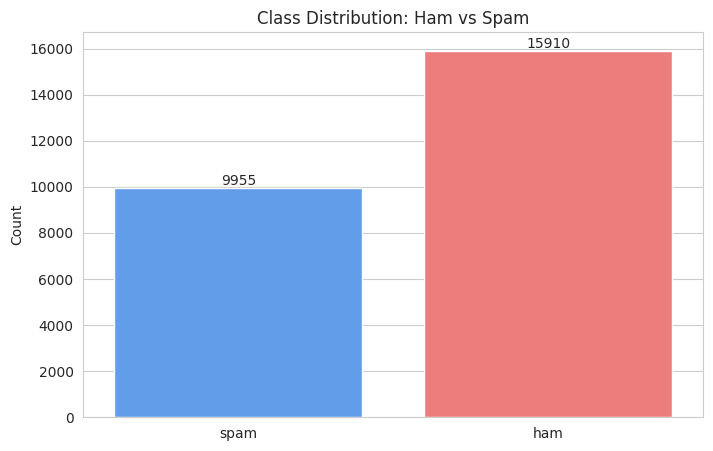

In [5]:
plt.figure()
ax = sns.countplot(x="Category", data=df, palette=["#4C9AFF", "#FF6B6B"])
plt.title("Class Distribution: Ham vs Spam")
plt.xlabel("")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


## 5. Feature engineering

Outlier detection needs numeric values, so we derive them from the raw message text.


In [6]:
df["char_count"] = df["Message"].apply(len)
df["word_count"] = df["Message"].apply(lambda x: len(x.split()))

df[["char_count", "word_count"]].describe()


,char_count,word_count
count,25865.000000,25865.000000
mean,1507.214421,313.896037
std,4400.425626,877.194044
min,3.000000,1.000000
25%,343.000000,72.000000
50%,728.000000,157.000000
75%,1581.000000,340.000000
max,228368.000000,45450.000000


## 6. Distribution vs. ideal normal curve — BEFORE outlier removal

The black line is a perfect bell curve using this data's own mean/std. The gap
between it and the real histogram shows how right-skewed the data is — the
justification for using the IQR method (not Z-score) for outlier detection.


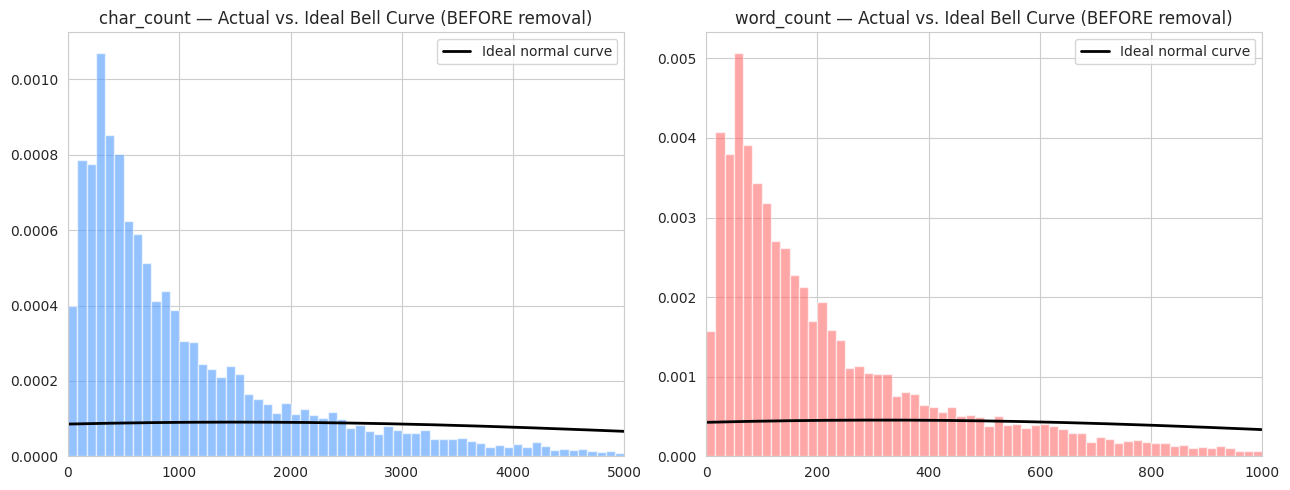

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
configs = [("char_count", "#4C9AFF", 5000), ("word_count", "#FF6B6B", 1000)]

for ax, (col, color, xlim) in zip(axes, configs):
    data = df[col]
    ax.hist(data, bins=60, range=(0, xlim), density=True, color=color, alpha=0.6, edgecolor="white")
    mu, sigma = data.mean(), data.std()
    x = np.linspace(0, xlim, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=2, label="Ideal normal curve")
    ax.set_xlim(0, xlim)
    ax.set_title(f"{col} — Actual vs. Ideal Bell Curve (BEFORE removal)")
    ax.legend()

plt.tight_layout()
plt.show()


## 7. Outlier detection (IQR method)

In [8]:
def iqr_outlier_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper

mask_char, low_c, up_c = iqr_outlier_mask(df["char_count"])
mask_word, low_w, up_w = iqr_outlier_mask(df["word_count"])
outlier_mask = mask_char | mask_word

print(f"char_count bounds: [{low_c:.1f}, {up_c:.1f}]")
print(f"word_count bounds: [{low_w:.1f}, {up_w:.1f}]")
print(f"Outliers flagged: {outlier_mask.sum()} out of {len(df)} rows ({outlier_mask.mean()*100:.2f}%)")
print()
print("Outlier breakdown by class:")
print(df[outlier_mask]["Category"].value_counts())


char_count bounds: [-1514.0, 3438.0]
word_count bounds: [-330.0, 742.0]
Outliers flagged: 2243 out of 25865 rows (8.67%)

Outlier breakdown by class:
Category
ham     1398
spam     845
Name: count, dtype: int64


In [9]:
df_clean = df[~outlier_mask].reset_index(drop=True)
print(f"Rows before: {len(df)} | after: {len(df_clean)} | removed: {len(df) - len(df_clean)}")


Rows before: 25865 | after: 23622 | removed: 2243


## 8. Distribution vs. ideal normal curve — AFTER outlier removal

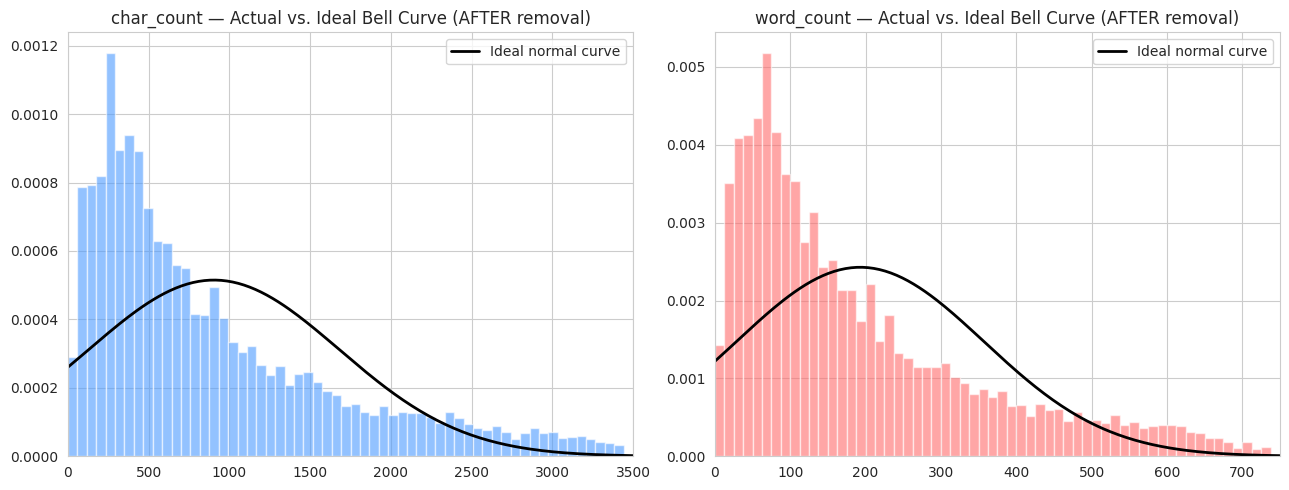

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
configs = [("char_count", "#4C9AFF", 3500), ("word_count", "#FF6B6B", 750)]

for ax, (col, color, xlim) in zip(axes, configs):
    data = df_clean[col]
    ax.hist(data, bins=60, range=(0, xlim), density=True, color=color, alpha=0.6, edgecolor="white")
    mu, sigma = data.mean(), data.std()
    x = np.linspace(0, xlim, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=2, label="Ideal normal curve")
    ax.set_xlim(0, xlim)
    ax.set_title(f"{col} — Actual vs. Ideal Bell Curve (AFTER removal)")
    ax.legend()

plt.tight_layout()
plt.show()


## 9. Model — before vs. after outlier removal

TF-IDF vectorization (fit only on training data) &rarr; Multinomial Naive Bayes.


=== Results (BEFORE outlier removal) ===
Accuracy  : 0.9731
Precision : 0.9701
Recall    : 0.9598
F1        : 0.9649

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98      3182
        spam       0.97      0.96      0.96      1991

    accuracy                           0.97      5173
   macro avg       0.97      0.97      0.97      5173
weighted avg       0.97      0.97      0.97      5173



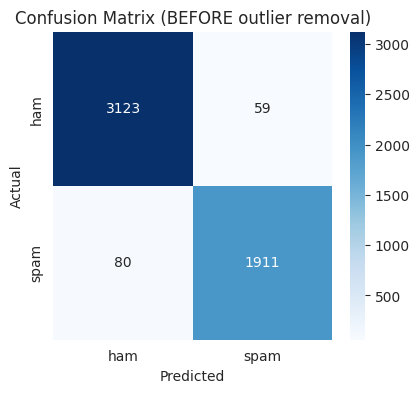

In [11]:
def run_pipeline(data, label_suffix=""):
    X_train, X_test, y_train, y_test = train_test_split(
        data["Message"], data["label_num"], test_size=0.2,
        random_state=RANDOM_STATE, stratify=data["label_num"]
    )

    tfidf_local = TfidfVectorizer(stop_words="english", max_features=3000)
    X_train_vec = tfidf_local.fit_transform(X_train)
    X_test_vec = tfidf_local.transform(X_test)

    model_local = MultinomialNB()
    model_local.fit(X_train_vec, y_train)
    preds_local = model_local.predict(X_test_vec)

    metrics = {
        "accuracy": accuracy_score(y_test, preds_local),
        "precision": precision_score(y_test, preds_local),
        "recall": recall_score(y_test, preds_local),
        "f1": f1_score(y_test, preds_local),
    }

    print(f"=== Results {label_suffix} ===")
    for k, v in metrics.items():
        print(f"{k.capitalize():10s}: {v:.4f}")
    print()
    print(classification_report(y_test, preds_local, target_names=["ham", "spam"]))

    cm = confusion_matrix(y_test, preds_local)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham","spam"], yticklabels=["ham","spam"])
    plt.title(f"Confusion Matrix {label_suffix}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    return metrics

metrics_before = run_pipeline(df, label_suffix="(BEFORE outlier removal)")


=== Results (AFTER outlier removal) ===
Accuracy  : 0.9759
Precision : 0.9662
Recall    : 0.9715
F1        : 0.9688

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98      2903
        spam       0.97      0.97      0.97      1822

    accuracy                           0.98      4725
   macro avg       0.97      0.98      0.97      4725
weighted avg       0.98      0.98      0.98      4725



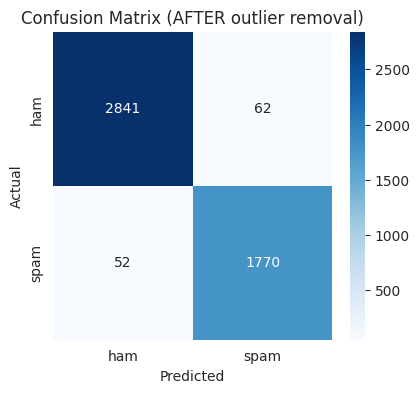

In [12]:
metrics_after = run_pipeline(df_clean, label_suffix="(AFTER outlier removal)")


In [13]:
comparison = pd.DataFrame({
    "Before outlier removal": metrics_before,
    "After outlier removal": metrics_after,
}).T
comparison


,accuracy,precision,recall,f1
Before outlier removal,0.973130,0.970051,0.959819,0.964908
After outlier removal,0.975873,0.966157,0.971460,0.968801


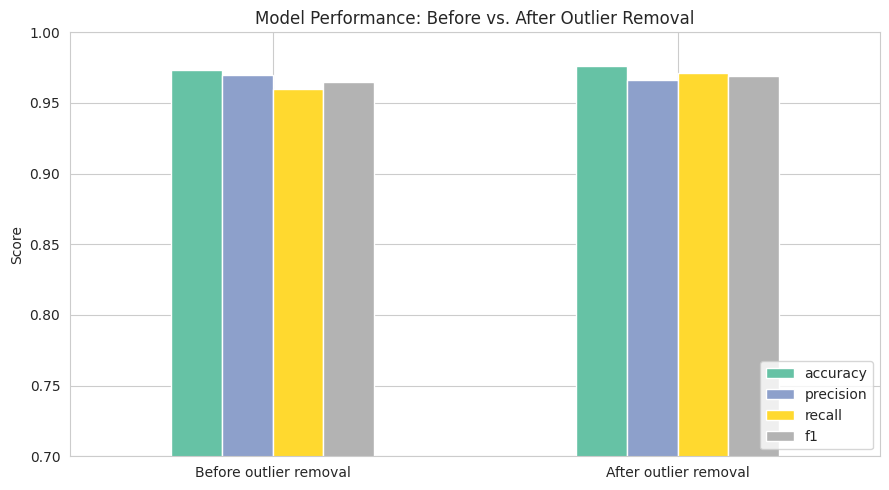

In [14]:
comparison.plot(kind="bar", figsize=(9, 5), colormap="Set2", ylim=(0.7, 1.0))
plt.title("Model Performance: Before vs. After Outlier Removal")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 10. Final model — full evaluation on outlier-cleaned data

Explicit train/test split (no leakage: TF-IDF is fit only on training data),
with the complete set of metrics including ROC-AUC and prediction confidence scores.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df_clean["Message"], df_clean["label_num"], test_size=0.2,
    random_state=RANDOM_STATE, stratify=df_clean["label_num"]
)
print(f"Training set size: {len(X_train)}")
print(f"Test set size:     {len(X_test)}")

tfidf = TfidfVectorizer(stop_words="english", max_features=3000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

preds = model.predict(X_test_vec)
probs = model.predict_proba(X_test_vec)


Training set size: 18897
Test set size:     4725


In [16]:
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)
roc_auc = roc_auc_score(y_test, probs[:, 1])

print("=== Final Model Performance (test set, outlier-cleaned data) ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print()
print(classification_report(y_test, preds, target_names=["ham", "spam"]))

cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:")
print(f"  True Negatives (ham correct):   {cm[0][0]}")
print(f"  False Positives (ham as spam):  {cm[0][1]}")
print(f"  False Negatives (spam as ham):  {cm[1][0]}")
print(f"  True Positives (spam correct):  {cm[1][1]}")


=== Final Model Performance (test set, outlier-cleaned data) ===
Accuracy:  0.9759
Precision: 0.9662
Recall:    0.9715
F1 Score:  0.9688
ROC-AUC:   0.9967

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98      2903
        spam       0.97      0.97      0.97      1822

    accuracy                           0.98      4725
   macro avg       0.97      0.98      0.97      4725
weighted avg       0.98      0.98      0.98      4725

Confusion Matrix:
  True Negatives (ham correct):   2841
  False Positives (ham as spam):  62
  False Negatives (spam as ham):  52
  True Positives (spam correct):  1770


In [17]:
results = pd.DataFrame({
    "Message": X_test.values[:10],
    "Actual": y_test.values[:10],
    "Predicted": preds[:10],
    "Confidence (spam)": probs[:10, 1].round(4)
})
results["Actual"] = results["Actual"].map({0: "ham", 1: "spam"})
results["Predicted"] = results["Predicted"].map({0: "ham", 1: "spam"})
pd.set_option("display.max_colwidth", 60)
results


,Message,Actual,Predicted,Confidence (spam)
0,hey bro - its done male pain - i need your help on this\...,spam,spam,0.9994
1,potential outsourcing customers for gas and financial wh...,ham,ham,0.0001
2,"chapter hi vince ,\n?\nhow are things with you ? well i ...",ham,ham,0.0481
3,re : turkey the group to whom this message was sent is r...,ham,ham,0.0000
4,"re : summer associate mentor ginger however , we encoura...",ham,ham,0.0548
5,an innovative plan for today ' s market give your client...,spam,spam,0.9909
6,"vince , congratulations on your promotion !\nregards ,\nnh",ham,ham,0.0732
7,"enron / hpl actuals for november 2 , 2000 teco tap 30 . ...",ham,ham,0.0001
8,bennington / lamar power ua 4 data call me with any ques...,ham,ham,0.0191
9,gas master all :\nattached you will find a clean and mar...,ham,ham,0.0173


## 11. Threshold tuning — precision/recall trade-off

The default classification threshold is 0.5. Lowering it catches more spam
(higher recall) at the cost of more false positives (lower precision).


In [18]:
thresholds = [0.5, 0.4, 0.3, 0.2]

print(f"{'Threshold':<12}{'Recall':<10}{'Precision':<12}{'False Pos':<12}{'False Neg':<10}")
print("-" * 56)

for t in thresholds:
    preds_t = (probs[:, 1] >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds_t)
    recall_t = recall_score(y_test, preds_t)
    precision_t = precision_score(y_test, preds_t)
    fp = cm_t[0][1]
    fn = cm_t[1][0]
    print(f"{t:<12}{recall_t:.4f}    {precision_t:.4f}      {fp:<12}{fn:<10}")


Threshold   Recall    Precision   False Pos   False Neg 
--------------------------------------------------------
0.5         0.9715    0.9662      62          52        
0.4         0.9808    0.9572      80          35        
0.3         0.9901    0.9455      104         18        
0.2         0.9951    0.9231      151         9         


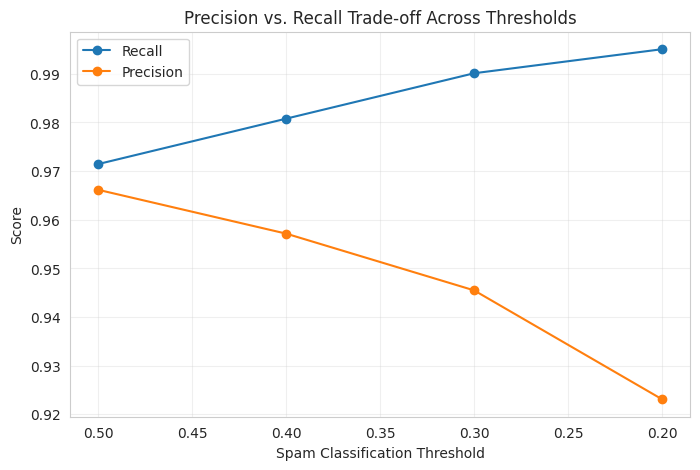

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, [recall_score(y_test, (probs[:,1]>=t).astype(int)) for t in thresholds], marker='o', label="Recall")
plt.plot(thresholds, [precision_score(y_test, (probs[:,1]>=t).astype(int)) for t in thresholds], marker='o', label="Precision")
plt.xlabel("Spam Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs. Recall Trade-off Across Thresholds")
plt.legend()
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.show()


## 12. Live prediction demo

In [20]:
def predict_message(text):
    vec = tfidf.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]

    label = "SPAM" if pred == 1 else "HAM"
    confidence = prob[pred] * 100

    print(f"Message: {text[:100]}{'...' if len(text) > 100 else ''}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"  (ham: {prob[0]*100:.2f}% | spam: {prob[1]*100:.2f}%)")
    print()


In [21]:
predict_message("Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!")
predict_message("Hey, are we still meeting for lunch tomorrow at 1pm?")
predict_message("URGENT: Your account will be suspended. Verify your password immediately at this link.")
predict_message("Please find attached the quarterly report for review before Friday's meeting.")


Message: Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!
Prediction: SPAM
Confidence: 95.98%
  (ham: 4.02% | spam: 95.98%)

Message: Hey, are we still meeting for lunch tomorrow at 1pm?
Prediction: HAM
Confidence: 96.37%
  (ham: 96.37% | spam: 3.63%)

Message: URGENT: Your account will be suspended. Verify your password immediately at this link.
Prediction: SPAM
Confidence: 74.68%
  (ham: 25.32% | spam: 74.68%)

Message: Please find attached the quarterly report for review before Friday's meeting.
Prediction: HAM
Confidence: 99.43%
  (ham: 99.43% | spam: 0.57%)

